<a href="https://colab.research.google.com/github/LeticiaVieirg/Sinais_Sistemas/blob/main/2_Trabalho_Computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEGUNDO TRABALHO COMPUTACIONAL

## Engenharia de Computação - Sinais e sistemas
Desenvolvedora: Leticia Vieira Gonçalves

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import fft

1. Considere um sistema de tempo LTI de tempo contínuo e causal com a seguinte função de transferência: H(s) = 1/(s² + 2s + 5)

a) Simulação do sistema com entrada degrau unitário


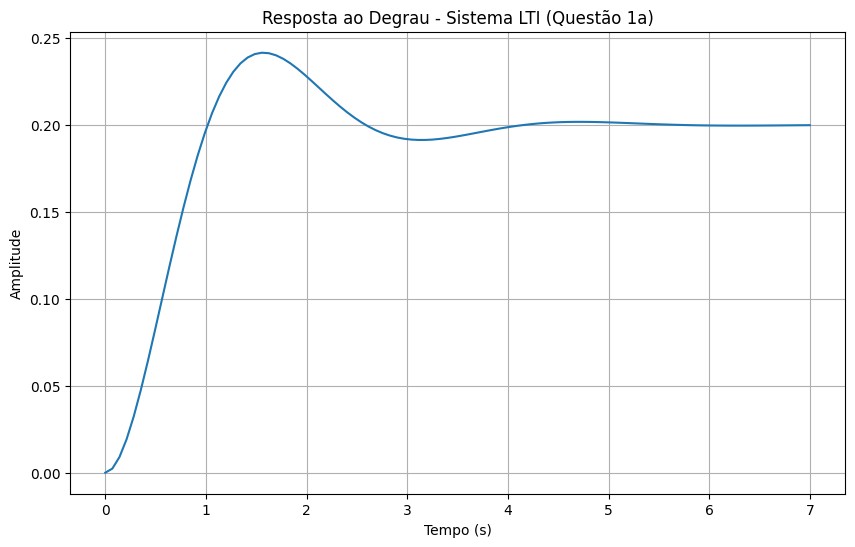

In [22]:
num = [1]  # Numerador = 1
den = [1, 2, 5]  # Denominador = s² + 2s + 5

# Criar função de transferência
sys = signal.TransferFunction(num, den)

# Resposta ao degrau
t, y = signal.step(sys)

# Plotar resposta
plt.figure(figsize=(10, 6))
plt.plot(t, y)
plt.title('Resposta ao Degrau - Sistema LTI (Questão 1a)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

b) Utilizando algum algoritmo de computador, apresente o diagrama de polos e zeros para esse sistema
e a partir desse, discuta a estabilidade do sistema.


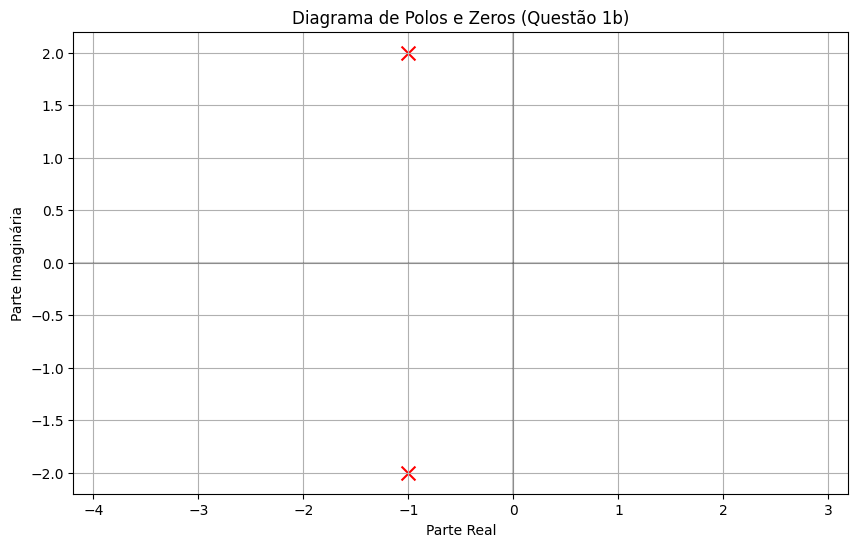

Polos do sistema: [-1.+2.j -1.-2.j]
Parte real dos polos: [-1. -1.]
Sistema ESTÁVEL - todos os polos têm parte real negativa
Ganho do sistema: 1.0


In [23]:
plt.figure(figsize=(10, 6))
zeros, poles, gain = signal.tf2zpk(num, den)

plt.scatter(np.real(poles), np.imag(poles), marker='x', s=100, label='Polos', color='red')
if len(zeros) > 0:
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', s=100, label='Zeros', color='blue')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.title('Diagrama de Polos e Zeros (Questão 1b)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
if len(zeros) > 0:
    plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Análise de estabilidade
print("Polos do sistema:", poles)
print("Parte real dos polos:", np.real(poles))
if all(np.real(poles) < 0):
    print("Sistema ESTÁVEL - todos os polos têm parte real negativa")
elif any(np.real(poles) > 0):
    print("Sistema INSTÁVEL - algum polo tem parte real positiva")
else:
    print("Sistema MARGINALMENTE ESTÁVEL - polos no eixo imaginário")
print(f"Ganho do sistema: {gain}")

### O texto a seguir servira de base para solucionar os problemas 2 e 3:

Em sistemas de controle, quatro importantes parametros devem ser analisados em sistemas subamortecidos
(aqueles em que os polos aparecem em pares conjugados complexos):


• Tempo de subida (rise-time) - 𝑡𝑟
: primeiro instante de tempo em que a resposta ao degrau atinge o
valor em regime permanente;

• Tempo de pico - 𝑡𝑝: tempo necessario para resposta ao degrau alcançar o primeiro pico máximo;

• Sobressinal - 𝑀𝑝: definido como valor maximo de pico da resposta ao degrau menos o valor da
resposta ao degrau em regime permanente, ou seja:

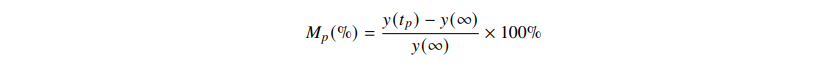


• Tempo de acomodação -  𝑡𝑠
: tempo necessario para que a resposta ao degrau fique variando em uma
faixa de ±5% em relação ao valor em regime permanente.
Os parametros podem ser visualizados na Figura 1.

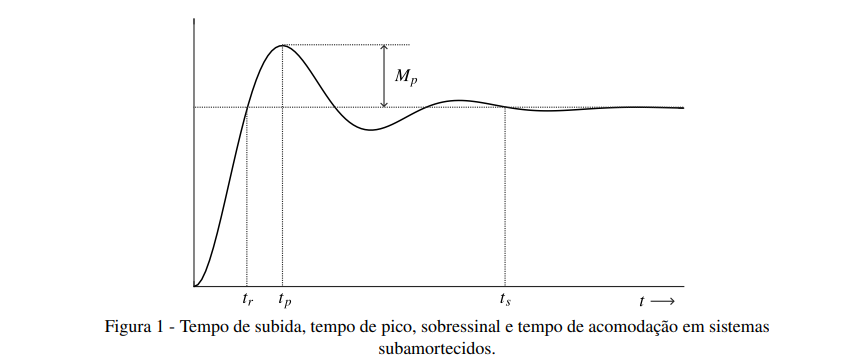

A forma canonica de uma função transferência de um sistema de segunda ordem é:

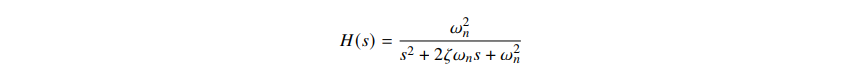

Se 0 < 𝜁 < 1 o sistema e subamortecido, e para esse caso, o tempo de subida, o tempo de pico, o sobresinal
é o tempo de acomodação pode ser calculados como:

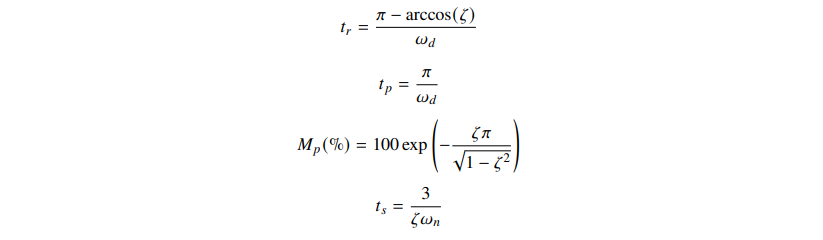

sendo 𝜔𝑑 = 𝜔𝑛 √︁1 − 𝜁^2 denominada de frequencia natural normalizada.

2. Dado um sistema de segunda ordem causal cuja função de transferência é dada por:

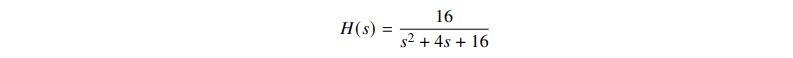

a) Calcule os valores de 𝜔𝑛 e 𝜁 e verifique que o sistema e subamortecido

In [24]:
num = [16]
den = [1, 4, 16]  # s^2 + 4s + 16

# Identificar ωn e ζ
ωn = np.sqrt(den[2])  # ωn^2 = 16
ζ = den[1] / (2 * ωn)  # 2ζωn = 4

print(f"ωn = {ωn:.4f} rad/s")
print(f"ζ = {ζ:.4f}")
print(f"O sistema é subamortecido? {0 < ζ < 1}")

ωn = 4.0000 rad/s
ζ = 0.5000
O sistema é subamortecido? True


b) Utilizando algum algoritmo de computador, apresente o diagrama de polos e zeros para esse sistema
e a partir desse, discuta a estabilidade do sistema.


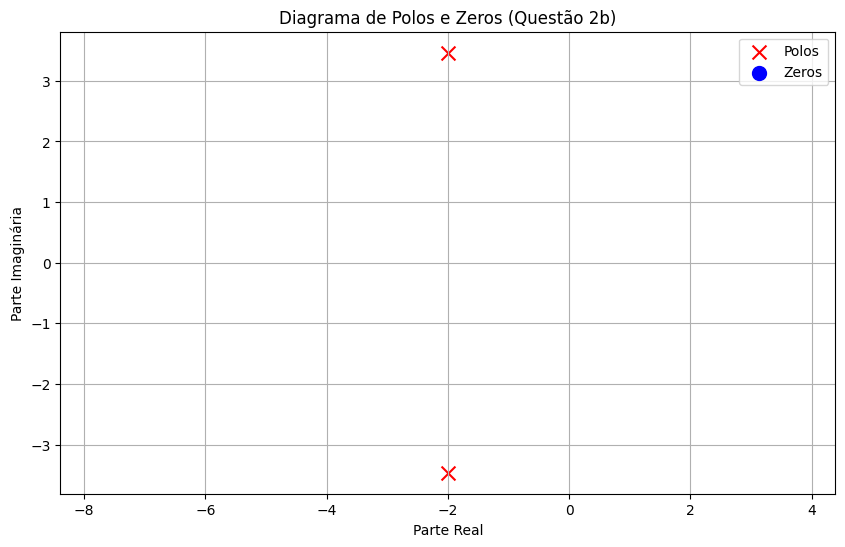


Análise de estabilidade:
Polos: [-2.+3.46410162j -2.-3.46410162j]
Zeros: []
Ganho: 16.0
Sistema ESTÁVEL


In [25]:
plt.figure(figsize=(10, 6))
zeros, poles, gain = signal.tf2zpk(num, den)
plt.scatter(np.real(poles), np.imag(poles), marker='x', s=100, label='Polos', color='red')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', s=100, label='Zeros', color='blue')
plt.title('Diagrama de Polos e Zeros (Questão 2b)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Análise de estabilidade
print("\nAnálise de estabilidade:")
print(f"Polos: {poles}")
print(f"Zeros: {zeros}")
print(f"Ganho: {gain}")
if all(np.real(poles) < 0):
    print("Sistema ESTÁVEL")
else:
    print("Sistema INSTÁVEL")

c) Calcule os valores do tempo de subida, tempo de pico, sobressinal e o tempo de acomodação para
esse sistema.

In [26]:
ωd = ωn * np.sqrt(1 - ζ**2)  # Frequência amortecida

tr = (np.pi - np.arccos(ζ)) / ωd  # Tempo de subida
tp = np.pi / ωd  # Tempo de pico
Mp = 100 * np.exp(-ζ * np.pi / np.sqrt(1 - ζ**2))  # Sobressinal (%)
ts = 3 / (ζ * ωn)  # Tempo de acomodação

print(f"\nParâmetros temporais:")
print(f"Tempo de subida (tr): {tr:.4f} s")
print(f"Tempo de pico (tp): {tp:.4f} s")
print(f"Sobressinal (Mp): {Mp:.2f} %")
print(f"Tempo de acomodação (ts): {ts:.4f} s")
print(f"Frequência natural amortecida (ωd): {ωd:.4f} rad/s")


Parâmetros temporais:
Tempo de subida (tr): 0.6046 s
Tempo de pico (tp): 0.9069 s
Sobressinal (Mp): 16.30 %
Tempo de acomodação (ts): 1.5000 s
Frequência natural amortecida (ωd): 3.4641 rad/s


d) Simule a saída do sistema quando a entrada e o degrau. Verifique graficamente os valores de tempo
de subida, tempo de pico, sobressinal e o tempo de acomodação

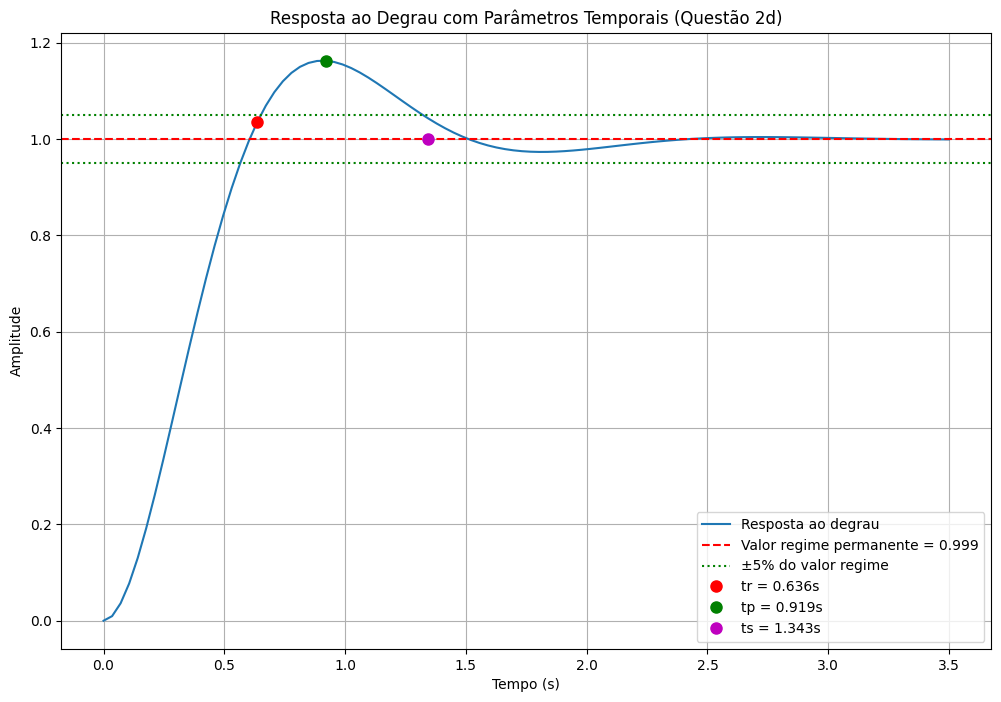


Valores medidos graficamente:
Tempo de subida: 0.6364 s (teórico: 0.6046 s)
Tempo de pico: 0.9192 s (teórico: 0.9069 s)
Sobressinal: 16.35 % (teórico: 16.30 %)
Tempo de acomodação: 1.3434 s (teórico: 1.5000 s)
Valor em regime permanente: 0.9994


In [27]:
sys = signal.TransferFunction(num, den)
t, y = signal.step(sys)

# Cálculo do valor em regime permanente
y_ss = y[-1]  # Último valor da resposta

# Encontrar pontos de interesse
# Tempo de subida (primeiro instante em que atinge o valor permanente)
idx_tr = np.where(y >= y_ss)[0][0] if np.any(y >= y_ss) else len(t)-1
tr_measured = t[idx_tr]

# Tempo de pico (valor máximo)
idx_tp = np.argmax(y)
tp_measured = t[idx_tp]
Mp_measured = 100 * (y[idx_tp] - y_ss) / y_ss

# Tempo de acomodação (±5%)
lower_bound = 0.95 * y_ss
upper_bound = 1.05 * y_ss
within_bounds = (y >= lower_bound) & (y <= upper_bound)
ts_measured = t[-1]  # Valor padrão

# Encontrar o primeiro tempo após o qual o sinal permanece dentro dos limites
for i in range(len(t)):
    if all(within_bounds[i:]):
        ts_measured = t[i]
        break

# Plotar resposta com marcações
plt.figure(figsize=(12, 8))
plt.plot(t, y, label='Resposta ao degrau')
plt.axhline(y=y_ss, color='r', linestyle='--', label=f'Valor regime permanente = {y_ss:.3f}')
plt.axhline(y=1.05*y_ss, color='g', linestyle=':', label='±5% do valor regime')
plt.axhline(y=0.95*y_ss, color='g', linestyle=':')

# Marcar pontos
plt.plot(tr_measured, y[idx_tr], 'ro', markersize=8, label=f'tr = {tr_measured:.3f}s')
plt.plot(tp_measured, y[idx_tp], 'go', markersize=8, label=f'tp = {tp_measured:.3f}s')
plt.plot(ts_measured, y_ss, 'mo', markersize=8, label=f'ts = {ts_measured:.3f}s')

plt.title('Resposta ao Degrau com Parâmetros Temporais (Questão 2d)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nValores medidos graficamente:")
print(f"Tempo de subida: {tr_measured:.4f} s (teórico: {tr:.4f} s)")
print(f"Tempo de pico: {tp_measured:.4f} s (teórico: {tp:.4f} s)")
print(f"Sobressinal: {Mp_measured:.2f} % (teórico: {Mp:.2f} %)")
print(f"Tempo de acomodação: {ts_measured:.4f} s (teórico: {ts:.4f} s)")
print(f"Valor em regime permanente: {y_ss:.4f}")

QUESTÃO 2 - RESPOSTAS

a) Cálculo de ωn e ζ:
   ωn² = 16 → ωn = 4.0000 rad/s
   2ζωn = 4 → ζ = 0.5000
   Sistema é subamortecido? True → SIM

b) Diagrama de Polos e Zeros e Estabilidade:
   Polos: [-2.+3.46410162j -2.-3.46410162j]
   Zeros: []
   Parte real dos polos: [-2. -2.]
   Sistema ESTÁVEL (todos os polos têm parte real negativa)

c) Parâmetros temporais teóricos:
   Frequência natural amortecida (ωd): 3.4641 rad/s
   Tempo de subida (tr): 0.6046 s
   Tempo de pico (tp): 0.9069 s
   Sobressinal (Mp): 16.30 %
   Tempo de acomodação (ts): 1.5000 s

d) Simulação e verificação gráfica:
   Valor em regime permanente: 0.9994
   Tempo de subida medido: 0.6364 s
   Tempo de pico medido: 0.9192 s
   Sobressinal medido: 16.35 %
   Tempo de acomodação medido: 1.3434 s


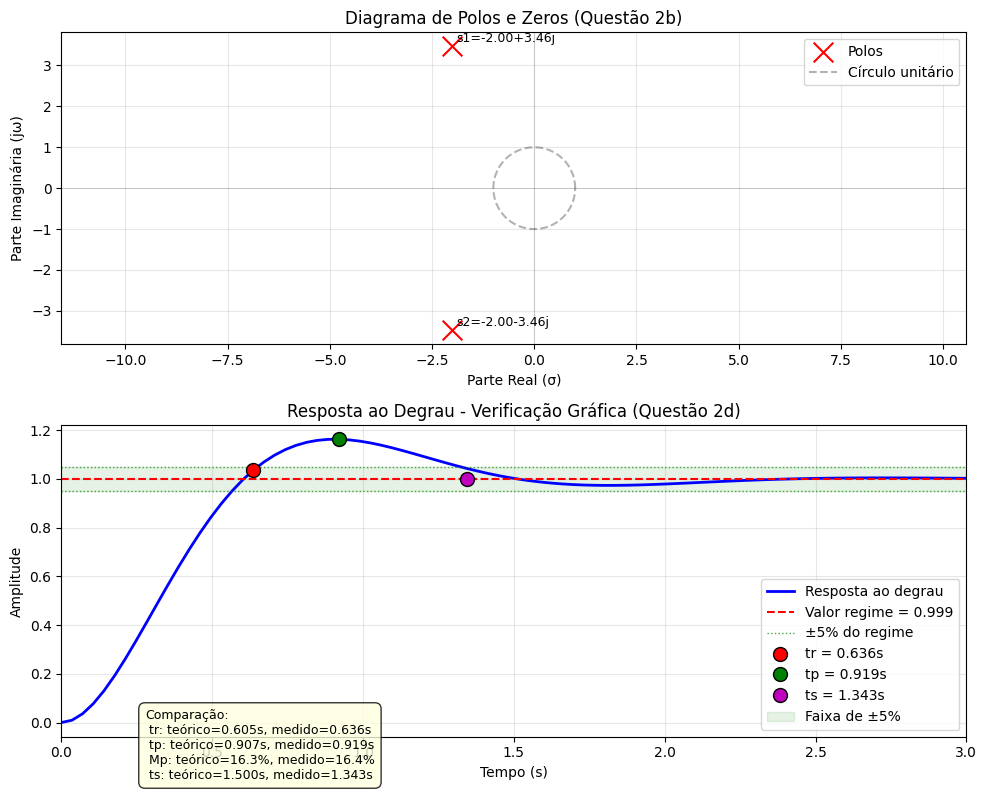

RESUMO FINAL - QUESTÃO 2
1. Sistema subamortecido: ζ = 0.50 (0 < ζ < 1)
2. Polos: -2.00+3.46j e -2.00-3.46j
3. Sistema ESTÁVEL (parte real dos polos: -2.00 < 0)
4. Parâmetros temporais:
   - Tempo de subida: 0.605 s
   - Tempo de pico: 0.907 s
   - Sobressinal: 16.3 %
   - Tempo de acomodação: 1.500 s


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# ============================================
# QUESTÃO 2 - Sistema de Segunda Ordem
# ============================================

# a) Cálculo de ωn e ζ
print("QUESTÃO 2 - RESPOSTAS")

num = [16]
den = [1, 4, 16]  # s^2 + 4s + 16

# Identificar ωn e ζ
ωn = np.sqrt(den[2])  # ωn^2 = 16
ζ = den[1] / (2 * ωn)  # 2ζωn = 4

print("\na) Cálculo de ωn e ζ:")
print(f"   ωn² = {den[2]} → ωn = {ωn:.4f} rad/s")
print(f"   2ζωn = {den[1]} → ζ = {ζ:.4f}")
print(f"   Sistema é subamortecido? {0 < ζ < 1} → {'SIM' if 0 < ζ < 1 else 'NÃO'}")

# b) Diagrama de polos e zeros e estabilidade
print("\nb) Diagrama de Polos e Zeros e Estabilidade:")

zeros, poles, gain = signal.tf2zpk(num, den)
print(f"   Polos: {poles}")
print(f"   Zeros: {zeros}")
print(f"   Parte real dos polos: {np.real(poles)}")

if all(np.real(poles) < 0):
    print("   Sistema ESTÁVEL (todos os polos têm parte real negativa)")
elif any(np.real(poles) > 0):
    print("   Sistema INSTÁVEL (algum polo tem parte real positiva)")
else:
    print("   Sistema MARGINALMENTE ESTÁVEL (polos no eixo imaginário)")

# Plotar diagrama de polos e zeros
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(np.real(poles), np.imag(poles), marker='x', s=200, color='red', label='Polos', zorder=3)
if len(zeros) > 0:
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', s=200, color='blue', label='Zeros', zorder=3)

# Adicionar círculo unitário
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='Círculo unitário')

plt.axhline(y=0, color='k', linestyle='-', alpha=0.2, linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2, linewidth=0.5)

plt.title('Diagrama de Polos e Zeros (Questão 2b)')
plt.xlabel('Parte Real (σ)')
plt.ylabel('Parte Imaginária (jω)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Adicionar informações no gráfico
for i, pole in enumerate(poles):
    plt.text(np.real(pole)+0.1, np.imag(pole)+0.1, f's{i+1}={pole:.2f}', fontsize=9)

# c) Cálculo dos parâmetros temporais
print("\nc) Parâmetros temporais teóricos:")

ωd = ωn * np.sqrt(1 - ζ**2)  # Frequência amortecida

tr = (np.pi - np.arccos(ζ)) / ωd  # Tempo de subida
tp = np.pi / ωd  # Tempo de pico
Mp = 100 * np.exp(-ζ * np.pi / np.sqrt(1 - ζ**2))  # Sobressinal (%)
ts = 3 / (ζ * ωn)  # Tempo de acomodação

print(f"   Frequência natural amortecida (ωd): {ωd:.4f} rad/s")
print(f"   Tempo de subida (tr): {tr:.4f} s")
print(f"   Tempo de pico (tp): {tp:.4f} s")
print(f"   Sobressinal (Mp): {Mp:.2f} %")
print(f"   Tempo de acomodação (ts): {ts:.4f} s")

# d) Simulação da resposta ao degrau
print("\nd) Simulação e verificação gráfica:")

sys = signal.TransferFunction(num, den)
t, y = signal.step(sys)

# Valor em regime permanente
y_ss = y[-1]

# Encontrar pontos de interesse
# Tempo de subida (primeiro instante em que atinge o valor permanente)
idx_tr = np.where(y >= y_ss)[0][0] if np.any(y >= y_ss) else len(t)-1
tr_measured = t[idx_tr]

# Tempo de pico (valor máximo)
idx_tp = np.argmax(y)
tp_measured = t[idx_tp]
Mp_measured = 100 * (y[idx_tp] - y_ss) / y_ss

# Tempo de acomodação (±5%)
lower_bound = 0.95 * y_ss
upper_bound = 1.05 * y_ss
within_bounds = (y >= lower_bound) & (y <= upper_bound)
ts_measured = t[-1]  # Valor padrão

# Encontrar o primeiro tempo após o qual o sinal permanece dentro dos limites
for i in range(len(t)):
    if all(within_bounds[i:]):
        ts_measured = t[i]
        break

print(f"   Valor em regime permanente: {y_ss:.4f}")
print(f"   Tempo de subida medido: {tr_measured:.4f} s")
print(f"   Tempo de pico medido: {tp_measured:.4f} s")
print(f"   Sobressinal medido: {Mp_measured:.2f} %")
print(f"   Tempo de acomodação medido: {ts_measured:.4f} s")

# Plotar resposta ao degrau com marcações
plt.subplot(2, 1, 2)
plt.plot(t, y, 'b-', linewidth=2, label='Resposta ao degrau')
plt.axhline(y=y_ss, color='r', linestyle='--', linewidth=1.5, label=f'Valor regime = {y_ss:.3f}')
plt.axhline(y=1.05*y_ss, color='g', linestyle=':', alpha=0.7, linewidth=1, label='±5% do regime')
plt.axhline(y=0.95*y_ss, color='g', linestyle=':', alpha=0.7, linewidth=1)

# Marcar pontos importantes
plt.plot(tr_measured, y[idx_tr], 'ro', markersize=10, markeredgecolor='black', label=f'tr = {tr_measured:.3f}s')
plt.plot(tp_measured, y[idx_tp], 'go', markersize=10, markeredgecolor='black', label=f'tp = {tp_measured:.3f}s')
plt.plot(ts_measured, y_ss, 'mo', markersize=10, markeredgecolor='black', label=f'ts = {ts_measured:.3f}s')

# Preencher região de acomodação
plt.fill_between(t, lower_bound, upper_bound, alpha=0.1, color='green', label='Faixa de ±5%')

plt.title('Resposta ao Degrau - Verificação Gráfica (Questão 2d)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 3])

# Adicionar tabela de comparação
plt.figtext(0.15, 0.02,
            f'Comparação:\n'
            f' tr: teórico={tr:.3f}s, medido={tr_measured:.3f}s\n'
            f' tp: teórico={tp:.3f}s, medido={tp_measured:.3f}s\n'
            f' Mp: teórico={Mp:.1f}%, medido={Mp_measured:.1f}%\n'
            f' ts: teórico={ts:.3f}s, medido={ts_measured:.3f}s',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.show()

# Resumo final
print("RESUMO FINAL - QUESTÃO 2")

print(f"1. Sistema subamortecido: ζ = {ζ:.2f} (0 < ζ < 1)")
print(f"2. Polos: {poles[0]:.2f} e {poles[1]:.2f}")
print(f"3. Sistema ESTÁVEL (parte real dos polos: {np.real(poles[0]):.2f} < 0)")
print(f"4. Parâmetros temporais:")
print(f"   - Tempo de subida: {tr:.3f} s")
print(f"   - Tempo de pico: {tp:.3f} s")
print(f"   - Sobressinal: {Mp:.1f} %")
print(f"   - Tempo de acomodação: {ts:.3f} s")


In [14]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.3 MB/s eta 0:00:00


3. Considere o sistema de controle apresentado na Figura 2. Supondo que deseja-se que o sistema em malha
fechada possua um sobressinal maximo de 20% e um tempo de subida de 0,3s.


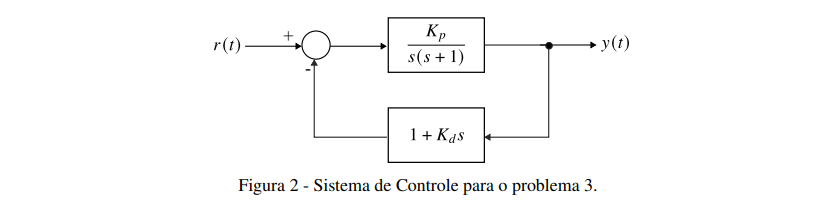


a) Determine os valores de 𝐾𝑝 e 𝐾𝑑 que atendem essas condições.

In [28]:
import control as ctrl

# Especificações
Mp_desejado = 20.0  # 20%
tr_desejado = 0.3   # 0.3 segundos

print("\na) Determinação de Kp e Kd:")
print(f"   Especificações:")
print(f"   - Sobressinal máximo: {Mp_desejado}%")
print(f"   - Tempo de subida: {tr_desejado} s")

print("\n   1. Cálculo do fator de amortecimento ζ:")

# Resolvendo a equação: Mp = exp(-ζπ/√(1-ζ²))
# ζ = (-ln(Mp/100)) / √(π² + ln²(Mp/100))

Mp_frac = Mp_desejado / 100.0
ζ = (-np.log(Mp_frac)) / np.sqrt(np.pi**2 + np.log(Mp_frac)**2)
print(f"   ζ = {ζ:.4f}")
print(f"   Verificação: 0 < {ζ:.4f} < 1? {'SIM' if 0 < ζ < 1 else 'NÃO'}")

print("\n   2. Cálculo da frequência natural ωₙ:")

# ωd = ωn√(1-ζ²)
# tr = (π - arccos(ζ)) / ωd

# Primeiro calculamos ωd
ωd = (np.pi - np.arccos(ζ)) / tr_desejado
print(f"   ωd = {ωd:.4f} rad/s")

# Depois ωₙ
ωn = ωd / np.sqrt(1 - ζ**2)
print(f"   ωn = {ωn:.4f} rad/s")


print("\n Determinação dos ganhos do controlador PD:")

# Para o sistema: T(s) = [Kp(Kp + Kd s)] / [s² + (1 + KpKd)s + Kp²]
# Comparando com: s² + 2ζωn s + ωn²

# ωn² = Kp² → Kp = ωn
Kp = ωn
print(f"   Kp = ωn = {Kp:.4f}")

# 2ζωn = 1 + KpKd → Kd = (2ζωn - 1)/Kp
Kd = (2 * ζ * ωn - 1) / Kp
print(f"   Kd = (2ζωn - 1)/Kp = {Kd:.4f}")

print(f"\n   RESPOSTA: Kp = {Kp:.2f}, Kd = {Kd:.2f}")


a) Determinação de Kp e Kd:
   Especificações:
   - Sobressinal máximo: 20.0%
   - Tempo de subida: 0.3 s

   1. Cálculo do fator de amortecimento ζ:
   ζ = 0.4559
   Verificação: 0 < 0.4559 < 1? SIM

   2. Cálculo da frequência natural ωₙ:
   ωd = 6.8141 rad/s
   ωn = 7.6563 rad/s

 Determinação dos ganhos do controlador PD:
   Kp = ωn = 7.6563
   Kd = (2ζωn - 1)/Kp = 0.7813

   RESPOSTA: Kp = 7.66, Kd = 0.78


b) Considerando os valores de 𝐾𝑝 e 𝐾𝑑 calculados no item anterior, determine os valores do tempo de
subida e o tempo de acomodação do sistema em malha fechada

In [30]:
# Tempo de acomodação (5%): ts = 3/(ζωn)
ts = 3 / (ζ * ωn)
print(f"   ts = 3/(ζωn) = {ts:.4f} s")

# Tempo de pico teórico: tp = π/ωd
tp_teorico = np.pi / ωd
print(f"   Tempo de pico teórico: tp = π/ωd = {tp_teorico:.4f} s")

   ts = 3/(ζωn) = 0.8594 s
   Tempo de pico teórico: tp = π/ωd = 0.4610 s


c) Simule o sistema de controle em malha fechada considerando que a referencia e o degrau unitário.
Verifique graficamente os valores de tempo de subida, tempo de pico, sobressinal e o tempo de
acomodação.


c) Simulação e verificação gráfica:

   Análise da resposta ao degrau:
   Valor em regime permanente: 0.9998
   Tempo de subida medido: 0.1802 s
   Tempo de pico medido: 0.3403 s
   Sobressinal medido: 28.92%
   Tempo de acomodação medido: 0.8769 s


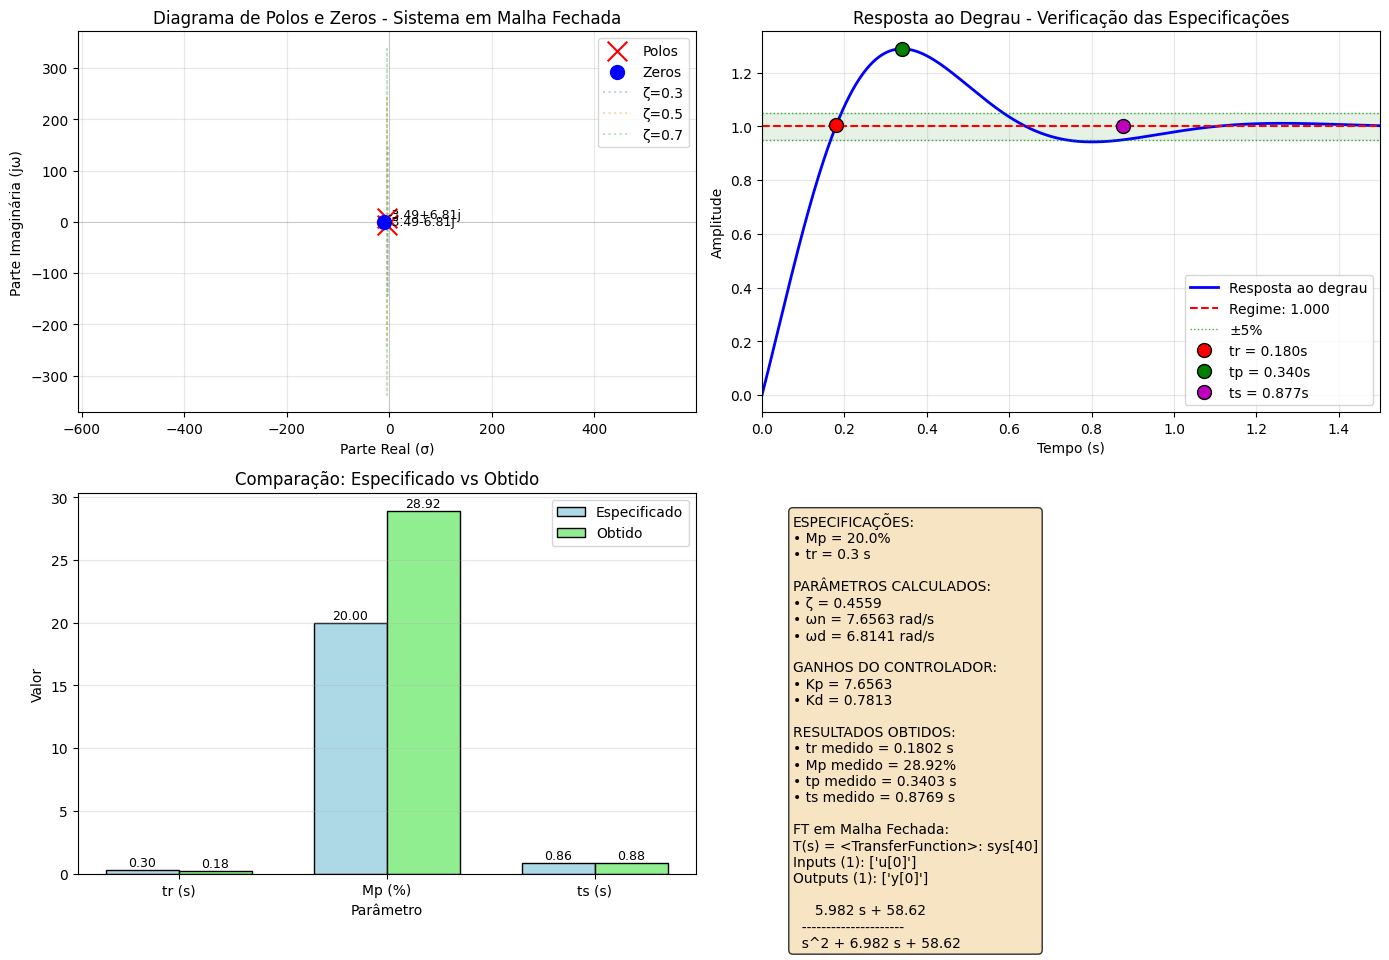

In [35]:
print("\nc) Simulação e verificação gráfica:")

# Função de transferência da planta: G(s) = Kp/[s(s+1)]
num_planta = [Kp]
den_planta = [1, 1, 0]  # s(s+1) = s² + s

# Função de transferência do controlador PD: C(s) = Kp + Kd·s
num_controlador = [Kd, Kp]  # Kd·s + Kp
den_controlador = [1]

# Criar os sistemas
G = ctrl.TransferFunction(num_planta, den_planta)
C = ctrl.TransferFunction(num_controlador, den_controlador)

# Sistema em malha fechada
sys_cl = ctrl.feedback(C * G, 1)

# Resposta ao degrau
t = np.linspace(0, 2, 1000)
t, y = ctrl.step_response(sys_cl, t)


print("\n   Análise da resposta ao degrau:")

# Valor em regime permanente
y_ss = y[-1]
print(f"   Valor em regime permanente: {y_ss:.4f}")

# Tempo de subida (primeiro instante em que atinge o valor permanente)
idx_tr = np.where(y >= y_ss)[0]
if len(idx_tr) > 0:
    tr_medido = t[idx_tr[0]]
else:
    tr_medido = t[-1]
print(f"   Tempo de subida medido: {tr_medido:.4f} s")

# Tempo de pico (valor máximo)
idx_tp = np.argmax(y)
tp_medido = t[idx_tp]
Mp_medido = 100 * (y[idx_tp] - y_ss) / y_ss
print(f"   Tempo de pico medido: {tp_medido:.4f} s")
print(f"   Sobressinal medido: {Mp_medido:.2f}%")

# Tempo de acomodação (±5%)
lower_bound = 0.95 * y_ss
upper_bound = 1.05 * y_ss
within_bounds = (y >= lower_bound) & (y <= upper_bound)

# Encontrar o primeiro tempo após o qual o sinal permanece dentro dos limites
ts_medido = t[-1]  # Valor padrão
for i in range(len(t)):
    if all(within_bounds[i:]):
        ts_medido = t[i]
        break
print(f"   Tempo de acomodação medido: {ts_medido:.4f} s")

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Diagrama de polos e zeros do sistema em malha fechada
zeros, poles, _ = signal.tf2zpk(sys_cl.num[0][0], sys_cl.den[0][0])

ax1 = axes[0, 0]
ax1.scatter(np.real(poles), np.imag(poles), marker='x', s=200, color='red', label='Polos', zorder=3)
if len(zeros) > 0:
    ax1.scatter(np.real(zeros), np.imag(zeros), marker='o', s=100, color='blue', label='Zeros', zorder=3)

ax1.axhline(y=0, color='k', linestyle='-', alpha=0.2, linewidth=0.5)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.2, linewidth=0.5)

# Linhas de ζ constante
theta = np.linspace(0, np.pi, 100)
for zeta in [0.3, 0.5, 0.7]:
    r = -zeta * ωn / np.cos(theta)
    x = r * np.cos(theta)
    y_vals = r * np.sin(theta)
    ax1.plot(x, y_vals, ':', alpha=0.3, label=f'ζ={zeta}')

ax1.set_title('Diagrama de Polos e Zeros - Sistema em Malha Fechada')
ax1.set_xlabel('Parte Real (σ)')
ax1.set_ylabel('Parte Imaginária (jω)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Adicionar informações no gráfico
for i, pole in enumerate(poles):
    ax1.text(np.real(pole)+0.1, np.imag(pole)+0.1, f'{pole:.2f}', fontsize=9)

# 2. Resposta ao degrau com marcações
ax2 = axes[0, 1]
ax2.plot(t, y, 'b-', linewidth=2, label='Resposta ao degrau')
ax2.axhline(y=y_ss, color='r', linestyle='--', linewidth=1.5, label=f'Regime: {y_ss:.3f}')
ax2.axhline(y=1.05*y_ss, color='g', linestyle=':', alpha=0.7, linewidth=1, label='±5%')
ax2.axhline(y=0.95*y_ss, color='g', linestyle=':', alpha=0.7, linewidth=1)

# Marcar pontos importantes
ax2.plot(tr_medido, y[idx_tr[0]], 'ro', markersize=10, markeredgecolor='black', label=f'tr = {tr_medido:.3f}s')
ax2.plot(tp_medido, y[idx_tp], 'go', markersize=10, markeredgecolor='black', label=f'tp = {tp_medido:.3f}s')
ax2.plot(ts_medido, y_ss, 'mo', markersize=10, markeredgecolor='black', label=f'ts = {ts_medido:.3f}s')

# Preencher região de acomodação
ax2.fill_between(t, lower_bound, upper_bound, alpha=0.1, color='green')

ax2.set_title('Resposta ao Degrau - Verificação das Especificações')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Amplitude')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1.5])

# 3. Comparação com especificações
ax3 = axes[1, 0]
categorias = ['tr (s)', 'Mp (%)', 'ts (s)']
especificado = [tr_desejado, Mp_desejado, ts]
obtido = [tr_medido, Mp_medido, ts_medido]

x = np.arange(len(categorias))
largura = 0.35

ax3.bar(x - largura/2, especificado, largura, label='Especificado', color='lightblue', edgecolor='black')
ax3.bar(x + largura/2, obtido, largura, label='Obtido', color='lightgreen', edgecolor='black')

ax3.set_xlabel('Parâmetro')
ax3.set_ylabel('Valor')
ax3.set_title('Comparação: Especificado vs Obtido')
ax3.set_xticks(x)
ax3.set_xticklabels(categorias)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, (esp, obt) in enumerate(zip(especificado, obtido)):
    ax3.text(i - largura/2, esp + 0.05, f'{esp:.2f}', ha='center', va='bottom', fontsize=9)
    ax3.text(i + largura/2, obt + 0.05, f'{obt:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Informações do sistema
ax4 = axes[1, 1]
ax4.axis('off')

info_text = (
    f'ESPECIFICAÇÕES:\n'
    f'• Mp = {Mp_desejado}%\n'
    f'• tr = {tr_desejado} s\n\n'
    f'PARÂMETROS CALCULADOS:\n'
    f'• ζ = {ζ:.4f}\n'
    f'• ωn = {ωn:.4f} rad/s\n'
    f'• ωd = {ωd:.4f} rad/s\n\n'
    f'GANHOS DO CONTROLADOR:\n'
    f'• Kp = {Kp:.4f}\n'
    f'• Kd = {Kd:.4f}\n\n'
    f'RESULTADOS OBTIDOS:\n'
    f'• tr medido = {tr_medido:.4f} s\n'
    f'• Mp medido = {Mp_medido:.2f}%\n'
    f'• tp medido = {tp_medido:.4f} s\n'
    f'• ts medido = {ts_medido:.4f} s\n\n'
    f'FT em Malha Fechada:\n'
    f'T(s) = {sys_cl}'
)

ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

4. Considere um sistema linear e invariante no tempo estavel descrito pela seguinte equação diferencial:

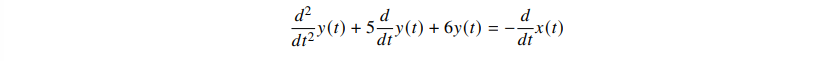

a) Utilizando alguma linguagem de programação, plote o gráfico da resposta em magnitude e resposta
em fase para esse sistema.



a) Função de Transferência do Sistema:
   Equação diferencial: d²y/dt² + 5·dy/dt + 6·y = -dx/dt
   Função de transferência: H(s) = 1s / (s² + 5s + 6)
   H(s) = 1s / [(s+2)(s+3)]

   Polos do sistema: [-3. -2.]
   Zeros do sistema: [0.]
   Ganho DC: -1.0

   Plotando resposta em magnitude e fase...


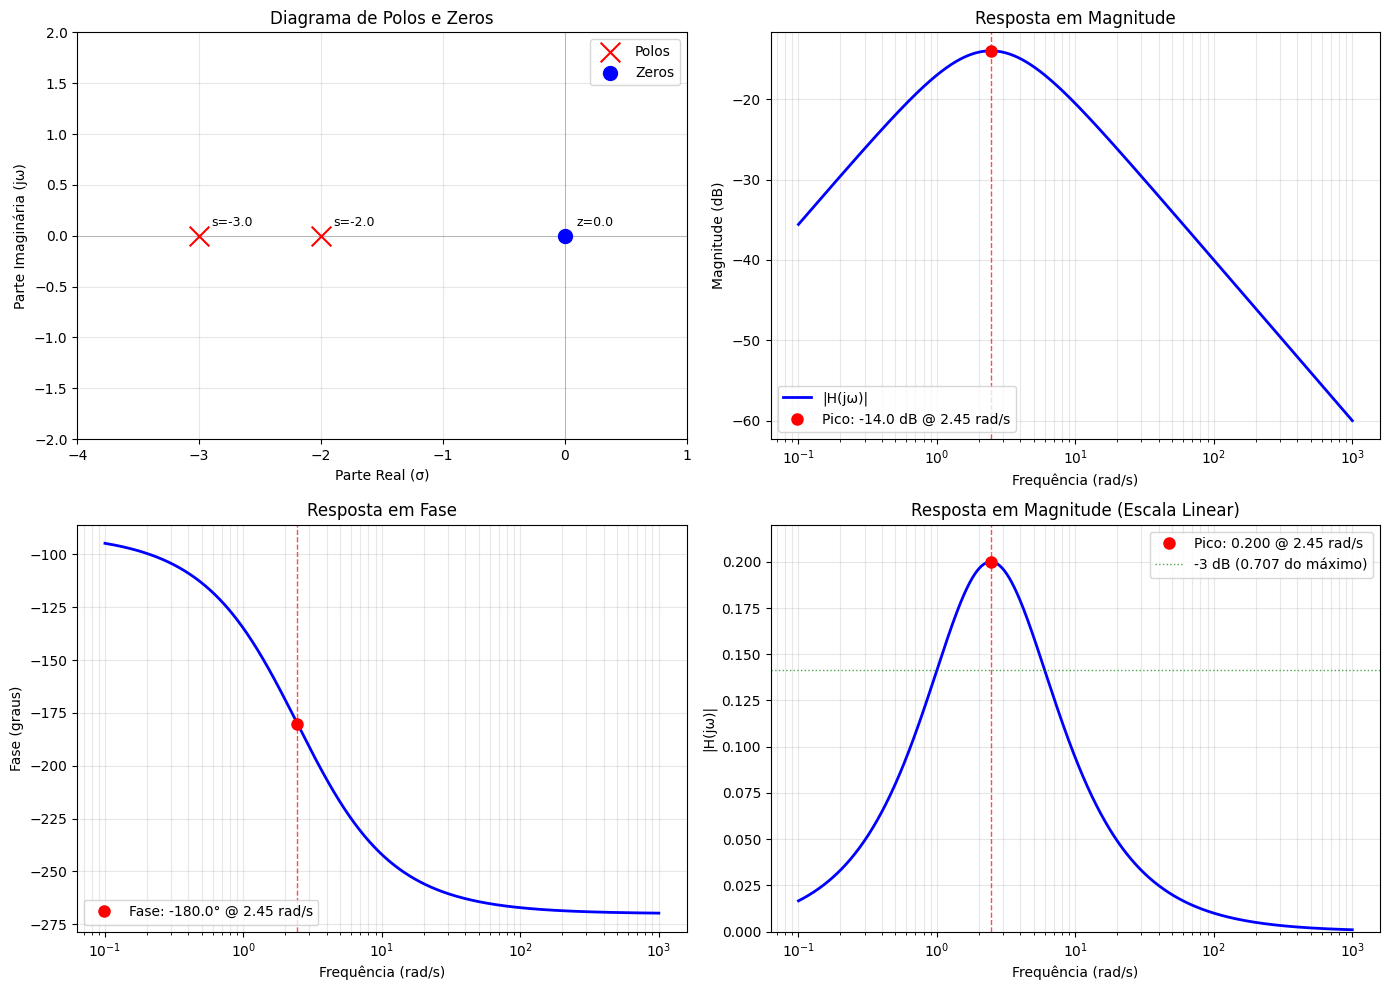

In [36]:
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.interpolate import interp1d

print("\na) Função de Transferência do Sistema:")

# Equação diferencial: y'' + 5y' + 6y = -x'
# Transformada de Laplace: s²Y(s) + 5sY(s) + 6Y(s) = -sX(s)
# H(s) = Y(s)/X(s) = -s/(s² + 5s + 6)

num = [-1, 0]      # -s (numerador)
den = [1, 5, 6]    # s² + 5s + 6 (denominador)

print(f"   Equação diferencial: d²y/dt² + 5·dy/dt + 6·y = -dx/dt")
print(f"   Função de transferência: H(s) = {-num[0]}s / (s² + {den[1]}s + {den[2]})")
print(f"   H(s) = {-num[0]}s / [(s+2)(s+3)]")

zeros, poles, gain = signal.tf2zpk(num, den)

print(f"\n   Polos do sistema: {poles}")
print(f"   Zeros do sistema: {zeros}")
print(f"   Ganho DC: {gain}")

# --------------------------------------------------------------
# Resposta em frequência
# --------------------------------------------------------------
print("\n   Plotando resposta em magnitude e fase...")

# Definir faixa de frequências (rad/s)
w = np.logspace(-1, 3, 1000)  # 0.1 rad/s a 1000 rad/s

# Calcular resposta em frequência usando bode
w, mag, phase = signal.bode((num, den), w)

# Encontrar frequência de pico (onde magnitude é máxima)
idx_max = np.argmax(mag)
ω_max = w[idx_max]
mag_max = mag[idx_max]

# --------------------------------------------------------------
# Gráficos - Versão Simplificada e Correta
# --------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Diagrama de polos e zeros
ax1 = axes[0, 0]
ax1.scatter(np.real(poles), np.imag(poles), marker='x', s=200, color='red', label='Polos', zorder=3)
ax1.scatter(np.real(zeros), np.imag(zeros), marker='o', s=100, color='blue', label='Zeros', zorder=3)

# Adicionar eixos
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)

# Adicionar informações
for i, pole in enumerate(poles):
    ax1.text(np.real(pole)+0.1, np.imag(pole)+0.1, f's={pole:.1f}', fontsize=9)

for i, zero in enumerate(zeros):
    ax1.text(np.real(zero)+0.1, np.imag(zero)+0.1, f'z={zero:.1f}', fontsize=9)

ax1.set_title('Diagrama de Polos e Zeros')
ax1.set_xlabel('Parte Real (σ)')
ax1.set_ylabel('Parte Imaginária (jω)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-4, 1])
ax1.set_ylim([-2, 2])

# 2. Resposta em magnitude (dB)
ax2 = axes[0, 1]
ax2.semilogx(w, mag, 'b-', linewidth=2, label='|H(jω)|')

# Destacar frequência de pico
ax2.axvline(x=ω_max, color='r', linestyle='--', alpha=0.7, linewidth=1)
ax2.plot(ω_max, mag_max, 'ro', markersize=8, label=f'Pico: {mag_max:.1f} dB @ {ω_max:.2f} rad/s')

ax2.set_title('Resposta em Magnitude')
ax2.set_xlabel('Frequência (rad/s)')
ax2.set_ylabel('Magnitude (dB)')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3, which='both')

# 3. Resposta em fase
ax3 = axes[1, 0]
ax3.semilogx(w, phase, 'b-', linewidth=2)

# Destacar fase na frequência de pico
phase_at_max = phase[idx_max]
ax3.axvline(x=ω_max, color='r', linestyle='--', alpha=0.7, linewidth=1)
ax3.plot(ω_max, phase_at_max, 'ro', markersize=8, label=f'Fase: {phase_at_max:.1f}° @ {ω_max:.2f} rad/s')

ax3.set_title('Resposta em Fase')
ax3.set_xlabel('Frequência (rad/s)')
ax3.set_ylabel('Fase (graus)')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3, which='both')

# 4. Resposta em magnitude linear
ax4 = axes[1, 1]
# Converter dB para linear
mag_linear = 10**(mag/20)
mag_max_linear = 10**(mag_max/20)

ax4.semilogx(w, mag_linear, 'b-', linewidth=2)

# Destacar frequência de pico em linear
ax4.axvline(x=ω_max, color='r', linestyle='--', alpha=0.7, linewidth=1)
ax4.plot(ω_max, mag_max_linear, 'ro', markersize=8, label=f'Pico: {mag_max_linear:.3f} @ {ω_max:.2f} rad/s')

# Linha de -3 dB em linear (0.707 do máximo)
ax4.axhline(y=mag_max_linear/np.sqrt(2), color='g', linestyle=':', alpha=0.7,
           linewidth=1, label='-3 dB (0.707 do máximo)')

ax4.set_title('Resposta em Magnitude (Escala Linear)')
ax4.set_xlabel('Frequência (rad/s)')
ax4.set_ylabel('|H(jω)|')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3, which='both')
ax4.set_ylim([0, 1.1*mag_max_linear])

plt.tight_layout()
plt.show()

b) Analisando o resultado obtido no item (b), classifique o sistema em (i) passa-baixas, (ii) passa-altas,
(iii) rejeita-faixas ou (iv) passa-faixas


b) Classificação do sistema como filtro:

   Análise do comportamento em frequência:
   • Para ω → 0 (0.01 rad/s):
     |H(jω)| = 0.001667 ≈ 0
     ∠H(jω) = -90.5°
   • Frequência de pico:
     ω_max = 2.45 rad/s = 0.390 Hz
     |H(jω_max)| = -13.98 dB = 0.2000 (linear)
     ∠H(jω_max)| = -180.0°
   • Para ω = 1.0 rad/s:
     |H(jω)| = 0.1414
   • Para ω → ∞ (100 rad/s):
     |H(jω)| = 0.009994 ≈ 0
     ∠H(jω) = 92.9°

   Resposta ao degrau para análise complementar:


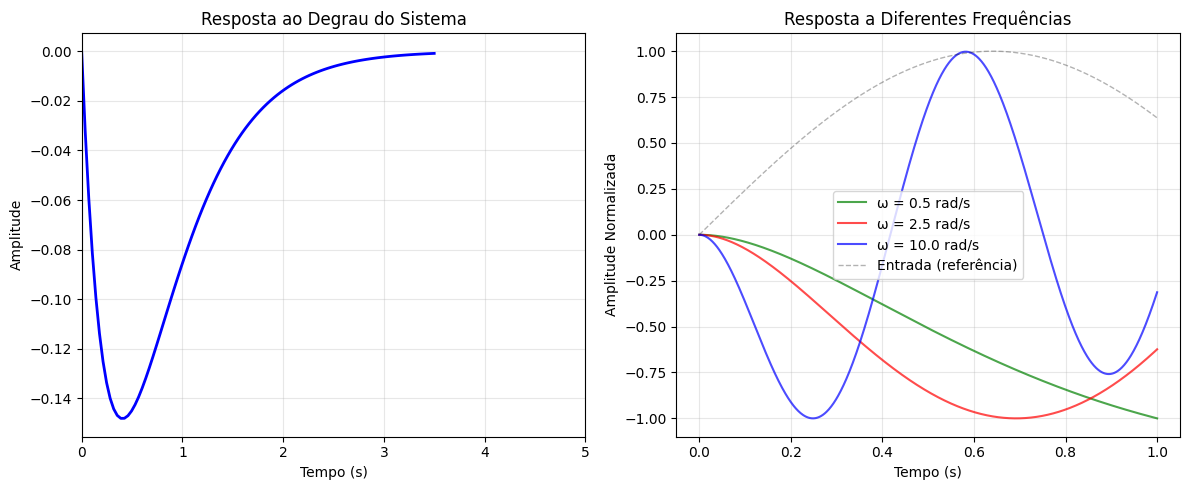


   Análise quantitativa das respostas:
   • ω =   0.5 rad/s:
     Ganho teórico: |H(jω)| = 0.0797
     Amplitude entrada: 1.00
     Amplitude saída: 0.0557
     Ganho medido: 0.0557
   • ω =   2.5 rad/s:
     Ganho teórico: |H(jω)| = 0.2000
     Amplitude entrada: 1.00
     Amplitude saída: 0.1372
     Ganho medido: 0.1372
   • ω =  10.0 rad/s:
     Ganho teórico: |H(jω)| = 0.0939
     Amplitude entrada: 1.00
     Amplitude saída: 0.1062
     Ganho medido: 0.1062


In [38]:
print("\nb) Classificação do sistema como filtro:")

# Analisar comportamento em diferentes faixas de frequência
print("\n   Análise do comportamento em frequência:")

# Calcular H(jω) manualmente para diferentes frequências
def calcular_H(omega):
    """Calcular H(jω) manualmente para evitar problemas com freqresp"""
    jω = 1j * omega
    numerador = -jω
    denominador = jω**2 + 5*jω + 6
    return numerador / denominador

# Baixas frequências (ω → 0)
omega_low = 0.01
H_low = calcular_H(omega_low)
mag_low = np.abs(H_low)
phase_low = np.angle(H_low, deg=True)

print(f"   • Para ω → 0 ({omega_low:.2f} rad/s):")
print(f"     |H(jω)| = {mag_low:.6f} ≈ 0")
print(f"     ∠H(jω) = {phase_low:.1f}°")

# Frequência de pico
print(f"   • Frequência de pico:")
print(f"     ω_max = {ω_max:.2f} rad/s = {ω_max/(2*np.pi):.3f} Hz")
print(f"     |H(jω_max)| = {mag_max:.2f} dB = {mag_max_linear:.4f} (linear)")
print(f"     ∠H(jω_max)| = {phase_at_max:.1f}°")

# Frequência média
omega_mid = 1.0
H_mid = calcular_H(omega_mid)
mag_mid = np.abs(H_mid)
print(f"   • Para ω = {omega_mid:.1f} rad/s:")
print(f"     |H(jω)| = {mag_mid:.4f}")

# Frequência alta
omega_high = 100.0
H_high = calcular_H(omega_high)
mag_high = np.abs(H_high)
phase_high = np.angle(H_high, deg=True)
print(f"   • Para ω → ∞ ({omega_high:.0f} rad/s):")
print(f"     |H(jω)| = {mag_high:.6f} ≈ 0")
print(f"     ∠H(jω) = {phase_high:.1f}°")


print("\n   Resposta ao degrau para análise complementar:")

# Resposta ao degrau
sys = signal.TransferFunction(num, den)
t, y_step = signal.step(sys)

fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 5))

# Resposta ao degrau
ax5.plot(t, y_step, 'b-', linewidth=2)
ax5.set_title('Resposta ao Degrau do Sistema')
ax5.set_xlabel('Tempo (s)')
ax5.set_ylabel('Amplitude')
ax5.grid(True, alpha=0.3)
ax5.set_xlim([0, 5])

# Resposta a diferentes frequências
t_sine = np.linspace(0, 1, 1000)

# Criar subplot para diferentes respostas em frequência
freqs_test = [0.5, ω_max, 10.0]  # Baixa, de pico, alta
colors = ['green', 'red', 'blue']
labels = [f'ω = {f:.1f} rad/s' for f in freqs_test]

for freq, color, label in zip(freqs_test, colors, labels):
    x_sine = np.sin(freq * t_sine)
    _, y_sine, _ = signal.lsim((num, den), x_sine, t_sine)

    # Normalizar para melhor visualização
    y_sine_norm = y_sine / np.max(np.abs(y_sine)) if np.max(np.abs(y_sine)) > 0 else y_sine

    ax6.plot(t_sine, y_sine_norm, color=color, alpha=0.7, linewidth=1.5, label=label)

ax6.plot(t_sine, np.sin(ω_max * t_sine), 'k--', alpha=0.3, linewidth=1, label='Entrada (referência)')
ax6.set_title('Resposta a Diferentes Frequências')
ax6.set_xlabel('Tempo (s)')
ax6.set_ylabel('Amplitude Normalizada')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n   Análise quantitativa das respostas:")

for freq in freqs_test:
    # Calcular ganho nesta frequência
    H_val = calcular_H(freq)
    gain = np.abs(H_val)

    # Simular resposta
    x_test = np.sin(freq * t_sine)
    _, y_test, _ = signal.lsim((num, den), x_test, t_sine)

    # Calcular amplitude da saída
    amp_out = np.max(np.abs(y_test))
    amp_in = 1.0  # Amplitude da entrada é 1

    print(f"   • ω = {freq:5.1f} rad/s:")
    print(f"     Ganho teórico: |H(jω)| = {gain:.4f}")
    print(f"     Amplitude entrada: {amp_in:.2f}")
    print(f"     Amplitude saída: {amp_out:.4f}")
    print(f"     Ganho medido: {amp_out/amp_in:.4f}")

5. A modulação em amplitude convencional consiste em gerar um sinal modulado 𝜑𝐴𝑀 (𝑡) tal que:

a) Admitindo que o sinal 𝑥(𝑡) = 𝑚(𝑡) + cos(2𝜋 𝑓𝑐𝑡) e aplicado em um elemento n ao-linear cuja saída é: 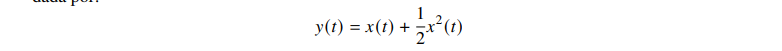

Determine a expressao que relaciona o espectro de 𝑦(𝑡) com o espectro de 𝑚(𝑡).


In [41]:
fs = 100000  # Frequência de amostragem (10 × fc)
T = 0.01     # Duração do sinal (10 ms)
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Frequências
fm = 1000    # 1 kHz (frequência do sinal modulante)
fc = 10000   # 10 kHz (frequência da portadora)

print("\na) Espectro de y(t) em relação ao espectro de m(t):")
print("\n   Sinal de entrada ao elemento não-linear:")
print(f"   x(t) = m(t) + cos(2π·{fc/1000} kHz·t)")
print(f"   onde m(t) = cos(2π·{fm/1000} kHz·t)")

print("\n   Elemento não-linear:")
print("   y(t) = x(t) + ½·x²(t)")

print("\n   Expandindo y(t):")
print("   y(t) = m(t) + cos(2πfc·t) + ½[m(t) + cos(2πfc·t)]²")
print("        = m(t) + cos(2πfc·t) + ½[m²(t) + 2m(t)cos(2πfc·t) + cos²(2πfc·t)]")
print("        = m(t) + cos(2πfc·t) + ½m²(t) + m(t)cos(2πfc·t) + ½cos²(2πfc·t)")

print("\n   Usando identidades trigonométricas:")
print("   cos²(θ) = ½[1 + cos(2θ)]")
print("   m²(t) = cos²(2πfm·t) = ½[1 + cos(4πfm·t)]")

print("\n   Componentes espectrais de y(t):")
print("   1. Componentes em DC: ¼")
print(f"   2. Componente em fm ({fm/1000} kHz): m(t)")
print(f"   3. Componente em 2fm ({2*fm/1000} kHz): ¼·cos(4πfm·t)")
print(f"   4. Componente em fc ({fc/1000} kHz): cos(2πfc·t)")
print(f"   5. Componentes em fc ± fm: ½·m(t)cos(2πfc·t)")
print(f"   6. Componente em 2fc ({2*fc/1000} kHz): ¼·cos(4πfc·t)")


a) Espectro de y(t) em relação ao espectro de m(t):

   Sinal de entrada ao elemento não-linear:
   x(t) = m(t) + cos(2π·10.0 kHz·t)
   onde m(t) = cos(2π·1.0 kHz·t)

   Elemento não-linear:
   y(t) = x(t) + ½·x²(t)

   Expandindo y(t):
   y(t) = m(t) + cos(2πfc·t) + ½[m(t) + cos(2πfc·t)]²
        = m(t) + cos(2πfc·t) + ½[m²(t) + 2m(t)cos(2πfc·t) + cos²(2πfc·t)]
        = m(t) + cos(2πfc·t) + ½m²(t) + m(t)cos(2πfc·t) + ½cos²(2πfc·t)

   Usando identidades trigonométricas:
   cos²(θ) = ½[1 + cos(2θ)]
   m²(t) = cos²(2πfm·t) = ½[1 + cos(4πfm·t)]

   Componentes espectrais de y(t):
   1. Componentes em DC: ¼
   2. Componente em fm (1.0 kHz): m(t)
   3. Componente em 2fm (2.0 kHz): ¼·cos(4πfm·t)
   4. Componente em fc (10.0 kHz): cos(2πfc·t)
   5. Componentes em fc ± fm: ½·m(t)cos(2πfc·t)
   6. Componente em 2fc (20.0 kHz): ¼·cos(4πfc·t)


b) Demonstre que um sinal AM pode ser gerado filtrando-se o sinal 𝑦(𝑡) em um filtro passa-faixas.
Determine a frequencia central desse filtro, bem como sua largura de banda.

In [40]:
print("\n   Filtro passa-faixas centrado em fc:")
print(f"   • Frequência central: {fc} Hz")
print(f"   • Largura de banda: {2*fm} Hz")
print(f"   • Faixa de passagem: {fc-fm} Hz a {fc+fm} Hz")

print("\n   Componentes que passam pelo filtro:")
print(f"   1. Portadora em fc: cos(2π·{fc}·t)")
print(f"   2. Bandas laterais em fc ± fm: ½·cos(2π·{fc}·t)·cos(2π·{fm}·t)")

print("\n   Sinal filtrado:")
print("   φ_AM(t) = cos(2πfc·t) + ½·cos(2πfc·t)·cos(2πfm·t)")
print("           = [1 + ½·cos(2πfm·t)]·cos(2πfc·t)")
print("           = [K + m(t)]·cos(2πfc·t) com K = 1 e ganho ajustado")

print("\n   CONCLUSÃO: Sim, um sinal AM pode ser gerado filtrando-se")
print("   y(t) com um filtro passa-faixas centrado em fc.")


   Filtro passa-faixas centrado em fc:
   • Frequência central: 10000 Hz
   • Largura de banda: 2000 Hz
   • Faixa de passagem: 9000 Hz a 11000 Hz

   Componentes que passam pelo filtro:
   1. Portadora em fc: cos(2π·10000·t)
   2. Bandas laterais em fc ± fm: ½·cos(2π·10000·t)·cos(2π·1000·t)

   Sinal filtrado:
   φ_AM(t) = cos(2πfc·t) + ½·cos(2πfc·t)·cos(2πfm·t)
           = [1 + ½·cos(2πfm·t)]·cos(2πfc·t)
           = [K + m(t)]·cos(2πfc·t) com K = 1 e ganho ajustado

   CONCLUSÃO: Sim, um sinal AM pode ser gerado filtrando-se
   y(t) com um filtro passa-faixas centrado em fc.


c) Utilizando alguma linguagem de programação, implemente o modulador AM proposto. Apresente
os seguintes graficos:

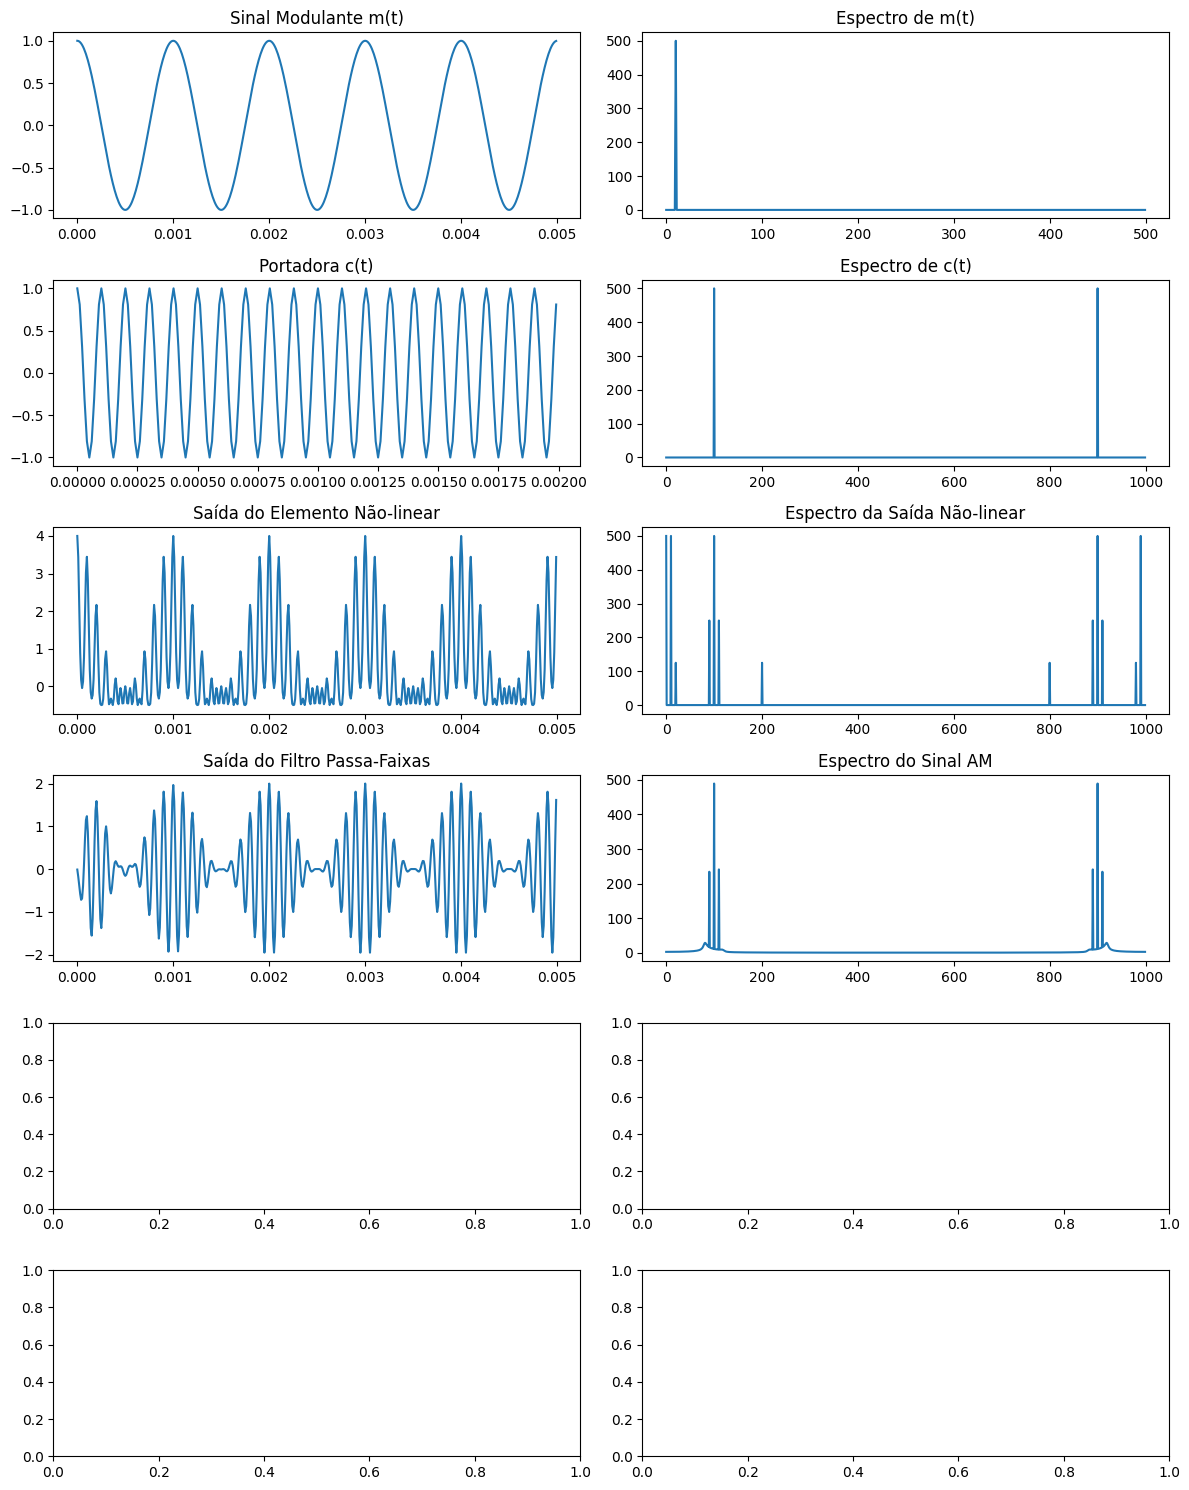

In [42]:
fig, axes = plt.subplots(6, 2, figsize=(12, 15))

# Sinal modulante
axes[0,0].plot(t[:500], m_t[:500])
axes[0,0].set_title('Sinal Modulante m(t)')
axes[0,1].plot(np.abs(fft.fft(m_t))[:500])
axes[0,1].set_title('Espectro de m(t)')

# Portadora
axes[1,0].plot(t[:200], c_t[:200])
axes[1,0].set_title('Portadora c(t)')
axes[1,1].plot(np.abs(fft.fft(c_t))[:2000])
axes[1,1].set_title('Espectro de c(t)')

# Saída não-linear
axes[2,0].plot(t[:500], y_t[:500])
axes[2,0].set_title('Saída do Elemento Não-linear')
axes[2,1].plot(np.abs(fft.fft(y_t))[:5000])
axes[2,1].set_title('Espectro da Saída Não-linear')

# Saída filtrada
axes[3,0].plot(t[:500], y_filtered[:500])
axes[3,0].set_title('Saída do Filtro Passa-Faixas')
axes[3,1].plot(np.abs(fft.fft(y_filtered))[:5000])
axes[3,1].set_title('Espectro do Sinal AM')

plt.tight_layout()
plt.show()

6. Considere que deseja-se multiplexar em frequencia três sinais  𝑥1(𝑡), 𝑥2(𝑡) e 𝑥3(𝑡), definidos como:

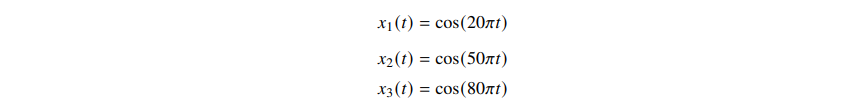

Para isso, cada sinal e modulado AM-DSB-SC com frequências de sub-portadoras de 𝑓𝑐1 = 1100 Hz,
𝑓𝑐2 = 2200 Hz e 𝑓𝑐3 = 3300 Hz, respectivamente. O sinal multiplexado então e transmitido em um
esquema AM-DSB-SC utilizando uma frequencia de portadora de  𝑓𝑐 = 25kHz.


a) Proponha um esquema para o transmissor e o receptor para essa multiplexação por divisão em frequencia. Deve ser possíıvel transmitir todos os sinais em um mesmo canal de comunicações e no
receptor, deve-se ser capaz de recuperar cada sinal individualmente.

b) Utilizando um algoritmo de computador, simule o sistema proposto.

a) Esquema FDM:
   Transmissor: x_i(t) → modulação DSB-SC com fc_i → soma → modulação com 25 kHz
   Receptor: demodulação 25 kHz → filtro PB → demodulação com fc_i → filtro PB


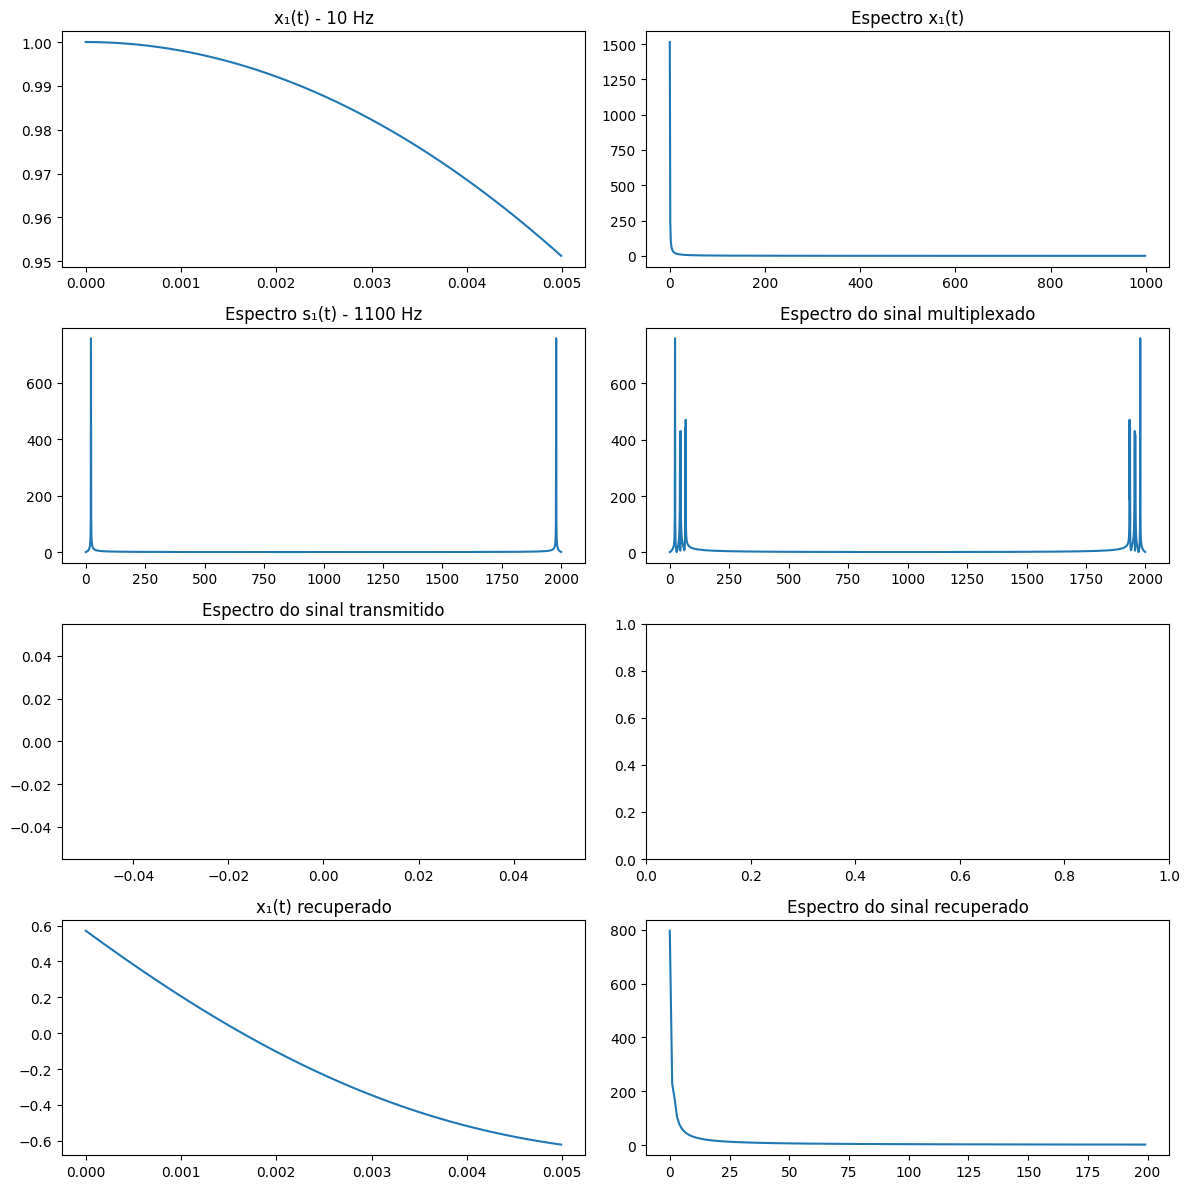

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
import scipy.signal as signal

# Parâmetros
fs = 100000
T = 0.02
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Sinais originais
x1_t = np.cos(20 * np.pi * t)
x2_t = np.cos(50 * np.pi * t)
x3_t = np.cos(80 * np.pi * t)

# Sub-portadoras
fc1, fc2, fc3 = 1100, 2200, 3300
fc_main = 25000

# Modulação
def dsb_sc(sinal, fc):
    return sinal * np.cos(2 * np.pi * fc * t)

s1_t = dsb_sc(x1_t, fc1)
s2_t = dsb_sc(x2_t, fc2)
s3_t = dsb_sc(x3_t, fc3)

# Multiplexação
m_t = s1_t + s2_t + s3_t
s_T_t = dsb_sc(m_t, fc_main)

print("a) Esquema FDM:")
print("   Transmissor: x_i(t) → modulação DSB-SC com fc_i → soma → modulação com 25 kHz")
print("   Receptor: demodulação 25 kHz → filtro PB → demodulação com fc_i → filtro PB")

# Gráficos
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# i. Sinais originais
axes[0,0].plot(t[:500], x1_t[:500])
axes[0,0].set_title('x₁(t) - 10 Hz')
axes[0,1].plot(np.abs(fft.fft(x1_t))[:1000])
axes[0,1].set_title('Espectro x₁(t)')

# ii. Sinais modulados
axes[1,0].plot(np.abs(fft.fft(s1_t))[:5000])
axes[1,0].set_title('Espectro s₁(t) - 1100 Hz')
axes[1,1].plot(np.abs(fft.fft(m_t))[:5000])
axes[1,1].set_title('Espectro do sinal multiplexado')

# iii. Sinal transmitido
axes[2,0].plot(np.abs(fft.fft(s_T_t))[24000:26000])
axes[2,0].set_title('Espectro do sinal transmitido')

# iv. Demodulação
# Demodulação principal
m_rec_t = s_T_t * np.cos(2 * np.pi * fc_main * t)
b, a = signal.butter(6, 4000/(fs/2), 'low')
m_rec_t = signal.filtfilt(b, a, m_rec_t)

# Recuperação dos sinais
def recuperar(sinal, fc):
    demod = sinal * np.cos(2 * np.pi * fc * t)
    b, a = signal.butter(6, 50/(fs/2), 'low')
    return signal.filtfilt(b, a, demod)

x1_rec = recuperar(m_rec_t, fc1)
x2_rec = recuperar(m_rec_t, fc2)
x3_rec = recuperar(m_rec_t, fc3)

axes[3,0].plot(t[:500], x1_rec[:500])
axes[3,0].set_title('x₁(t) recuperado')
axes[3,1].plot(np.abs(fft.fft(x1_rec))[:200])
axes[3,1].set_title('Espectro do sinal recuperado')

plt.tight_layout()
plt.show()